In [1]:
import os
import glob
import os
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from tqdm import tqdm
from scipy.signal import savgol_filter
import time
from scanpy.tools._utils import get_init_pos_from_paga 
from sklearn.metrics import mean_squared_error
from scipy.stats import zscore
from matplotlib.transforms import blended_transform_factory
import warnings
from matplotlib.lines import Line2D

import rmm
import cupy
import cudf
import cupy as cp
from rmm.allocators.cupy import rmm_cupy_allocator
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

from cuml.manifold import UMAP
from cuml.decomposition import TruncatedSVD

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

from tqdm.notebook import tqdm

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/TrajNet_input.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 523 ms, sys: 4.73 s, total: 5.25 s
Wall time: 8.6 s


AnnData object with n_obs × n_vars = 6895 × 15906
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz', 'velocyto_cell_id', 'cell_id', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'leiden', 'cluster_phase', 'early_g1_score', 'G1_stage', 'global_ordering', 'global_ordering_bin', 'velocity_self_tra

In [3]:
cell_cycle_genes = [x.strip() for x in open('../resources/regev_lab_cell_cycle_genes.txt')]

s_genes = [x for x in cell_cycle_genes[:43] if x in adata.var_names]
g2m_genes = [x for x in cell_cycle_genes[43:] if x in adata.var_names]

print(f"Total cell cycle genes in file: {len(cell_cycle_genes)}")
print(f"S-phase genes available in adata: {len(s_genes)} / 43")
print(f"G2M-phase genes available in adata: {len(g2m_genes)} / {len(cell_cycle_genes) - 43}")
print("\nFirst few S-phase genes found:", s_genes[:10])
print("First few G2M-phase genes found:", g2m_genes[:10])

Total cell cycle genes in file: 97
S-phase genes available in adata: 42 / 43
G2M-phase genes available in adata: 52 / 54

First few S-phase genes found: ['MCM5', 'PCNA', 'TYMS', 'FEN1', 'MCM2', 'MCM4', 'RRM1', 'UNG', 'GINS2', 'MCM6']
First few G2M-phase genes found: ['HMGB2', 'CDK1', 'NUSAP1', 'UBE2C', 'BIRC5', 'TPX2', 'TOP2A', 'NDC80', 'CKS2', 'NUF2']


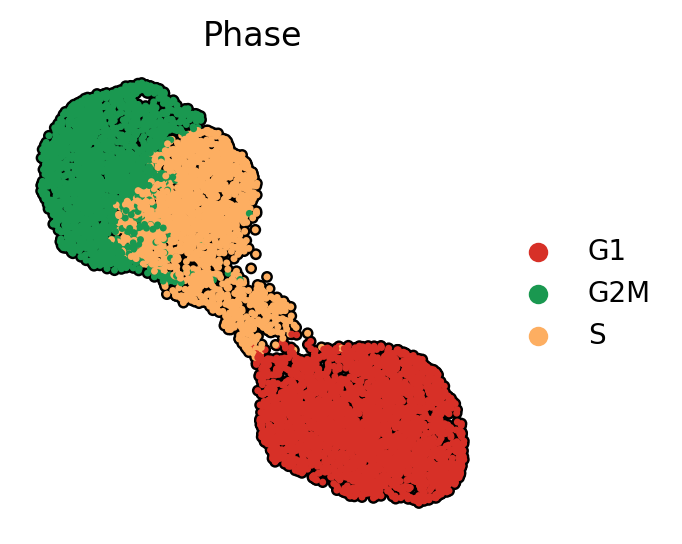

In [4]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

palette = {
    "G1": "#D73027",        
    "S": "#FDAE61",       
    "G2M": "#1A9850",    
    "unknown": "#B0B0B0", 
}
    
sc.pl.umap(
    adata,
    color='cluster_phase',
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    palette=palette,
    title='Phase',
    frameon=False,
    wspace=0.25,
)

# Add time mapping

In [5]:
# --- Config ---
dur_h = {'G1': 11.0, 'S': 8.0, 'G2M': 4.0}
order = ['G1', 'S', 'G2M']

# --- Derived quantities ---
T = float(sum(dur_h.values()))  # total hours
frac = {k: dur_h[k] / T for k in order}

offset_frac = pd.Series(
    [0.0] + list(np.cumsum([frac[p] for p in order[:-1]])),
    index=order
).to_dict()

# Optional: enforce ordered categories for safety (NA for unexpected labels)
adata.obs['cluster_phase'] = pd.Categorical(
    adata.obs['cluster_phase'],
    categories=order,
    ordered=True
)

# within-phase percentile u ∈ [0,1]
u = (
    adata.obs.groupby('cluster_phase')['global_ordering']
    .transform(lambda x: (x.rank(method='first') - 1) / max(len(x) - 1, 1))
)

# map to global fraction and hours
phase_off   = adata.obs['cluster_phase'].map(offset_frac).astype(float)
phase_frac  = adata.obs['cluster_phase'].map(frac).astype(float)
global_frac = (phase_off + u * phase_frac).astype(float)
cycle_time_h = global_frac * T  # in hours

# --- Write to obs ---
adata.obs['within_phase_pct'] = u.values
adata.obs['phase_offset_frac'] = phase_off.values
adata.obs['phase_frac'] = phase_frac.values
adata.obs['global_frac'] = global_frac.values
adata.obs['cycle_time_h'] = cycle_time_h.values

# 0–(T-1) discrete cycle hour (nullable int)
adata.obs['cycle_hour'] = pd.cut(
    cycle_time_h,
    bins=np.arange(0, int(T) + 1),
    labels=False,
)
adata.obs.head()

/tmp/ipykernel_1002482/1646062548.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('cluster_phase')['global_ordering']


,batch,phase,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,...,global_ordering_bin,velocity_self_transition,velocity_pseudotime,sample_labels,within_phase_pct,phase_offset_frac,phase_frac,global_frac,cycle_time_h,cycle_hour
AAACCAAAGGGTAGCA-1,fib,G2M,4551,8.423322,20400.0,9.923339,26.637255,37.632353,48.764706,63.382353,...,15,0.161565,0.888904,4,0.820540,0.478261,0.347826,0.763666,17.564320,17.0
AAACCAAAGTAAGGGT-1,fib,G1,2799,7.937375,10160.0,9.226312,31.633858,43.887795,55.551181,69.793307,...,2,0.000000,0.086364,0,0.305449,0.000000,0.478261,0.146085,3.359944,3.0
AAACCATTCAGGTAGG-1,fib,G2M,4536,8.420021,20040.0,9.905535,26.007984,36.182635,47.215569,62.255489,...,21,0.129804,0.953022,5,0.905749,0.826087,0.173913,0.983609,22.622997,22.0
AAACCATTCCAGCCCT-1,fib,G1,3053,8.024207,13256.0,9.492281,33.607423,47.555824,59.195836,72.789680,...,8,0.093623,0.178467,2,0.877820,0.000000,0.478261,0.419827,9.656022,9.0
AAACCATTCGTGACCG-1,fib,G1,3221,8.077758,11545.0,9.354094,28.150715,39.081854,50.281507,65.656128,...,1,0.154547,0.054163,0,0.119056,0.000000,0.478261,0.056940,1.309615,1.0


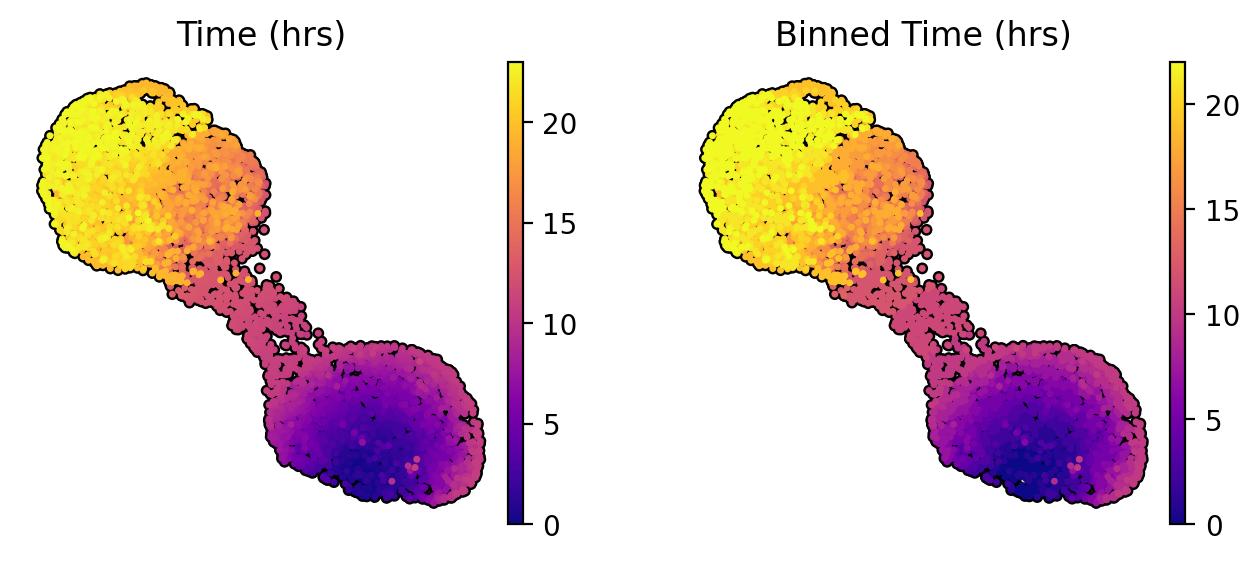

In [6]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.umap(
    adata,
    color=['cycle_time_h', 'cycle_hour'],
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    cmap='plasma',
    add_outline=True,
    outline_color=('k', 'k'),
    title=['Time (hrs)', 'Binned Time (hrs)'], 
    frameon=False,
    wspace=0.25,
)

# Agg by Time

In [7]:
%%time
layer = 'scvi'

# Agg by hour
aggdata = sc.get.aggregate(
    adata[adata.obs['cycle_hour'].notna(), :].copy(), # handle NaNs
    axis=0,
    by='cycle_hour',
    func=['mean', 'var'],
    layer=layer,
)

aggdata

CPU times: user 2.95 s, sys: 5.78 s, total: 8.73 s
Wall time: 8.75 s


AnnData object with n_obs × n_vars = 23 × 15906
    obs: 'cycle_hour'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'feature_id', 'gene_count_corr', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    layers: 'var', 'mean'

Text(0.5, 0, 'Time (hrs)')

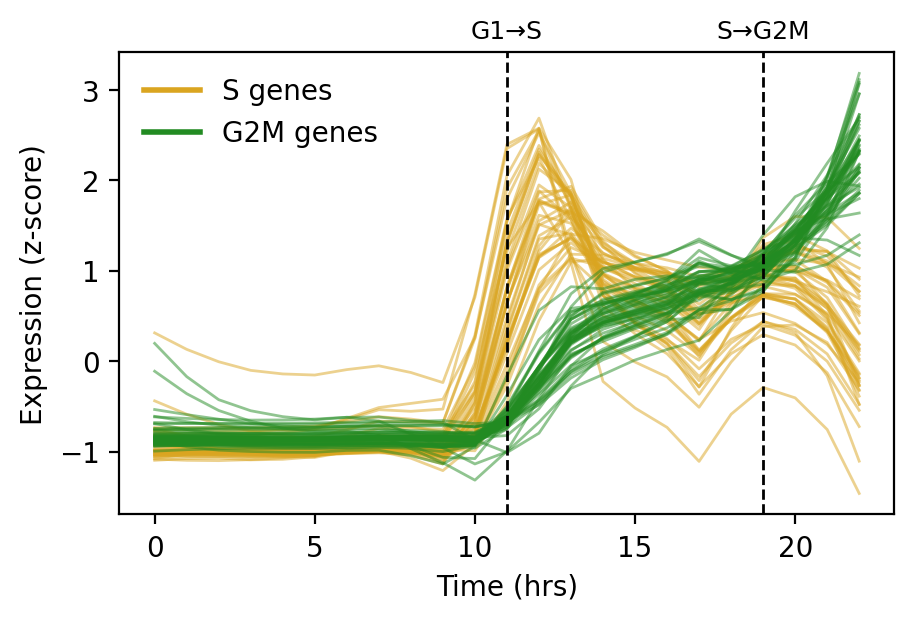

In [8]:
df = aggdata.to_df(layer='mean')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3

for gene in s_genes:
    x=df.index.astype(float).values
    y=zscore(df[gene].values)

    win = 5 if len(y) >= 7 else (len(y)//2)*2 + 1  # odd, ≤ len(y)
    y_sg = savgol_filter(y, window_length=win, polyorder=2, mode='interp')

    sns.lineplot(
        x=x, y=y_sg,
        lw=1., c='goldenrod', alpha=0.5,
    )

for gene in g2m_genes:
    x=df.index.astype(float).values
    y=zscore(df[gene].values)

    win = 5 if len(y) >= 7 else (len(y)//2)*2 + 1  # odd, ≤ len(y)
    y_sg = savgol_filter(y, window_length=win, polyorder=2, mode='interp')

    sns.lineplot(
        x=x, y=y_sg,
        lw=1., c='forestgreen', alpha=0.5,
    )

ax = plt.gca()
# ... (your plotting loops) ...

handles = [
    Line2D([0], [0], color='goldenrod', lw=2, label='S genes'),
    Line2D([0], [0], color='forestgreen', lw=2, label='G2M genes'),
]
ax.legend(handles=handles, loc='upper left', frameon=False)

order = ['G1','S','G2M']
ax = plt.gca()
trans = blended_transform_factory(ax.transData, ax.transAxes)

cum = 0.0
for i, phase in enumerate(order[:-1]):
    cum += dur_h[phase]  # boundary after this phase
    ax.axvline(cum, ls='--', lw=1, color='k')
    ax.text(cum, 1.02, f"{phase}→{order[i+1]}",
            transform=trans, ha='center', va='bottom',
            fontsize=9, clip_on=False)  # top of plot

plt.ylabel('Expression (z-score)')
plt.xlabel('Time (hrs)')

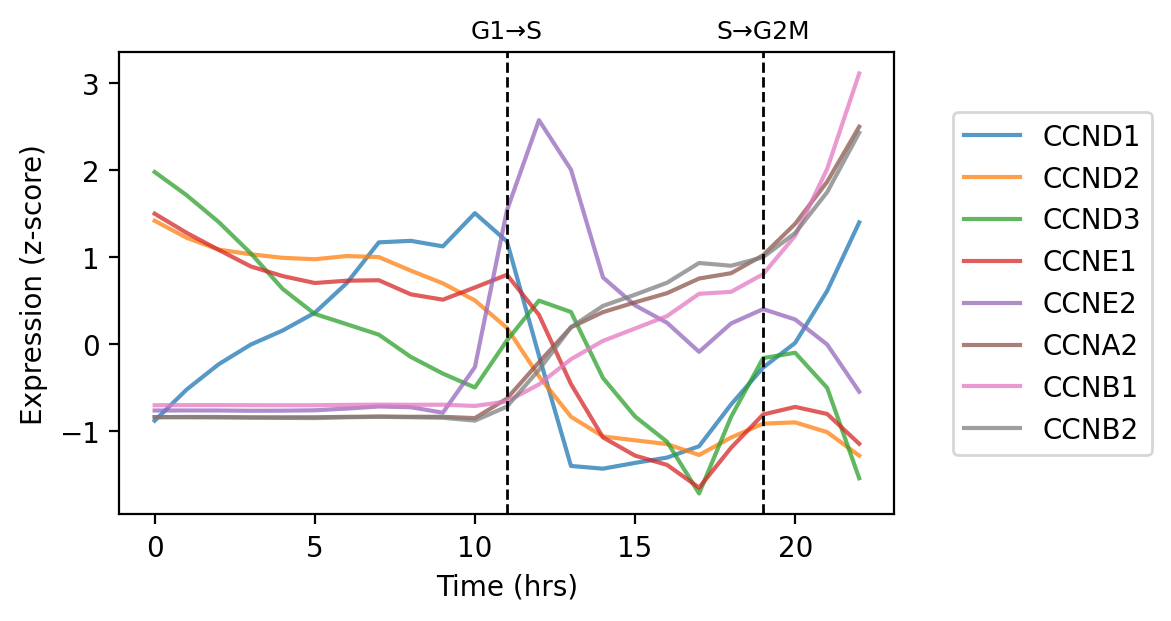

In [19]:
df = aggdata.to_df(layer='mean')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3

cyclin_genes = [
    "CCND1", "CCND2", "CCND3",   # G1 cyclins
    "CCNE1", "CCNE2",            # G1/S cyclins
    "CCNA1", "CCNA2",            # S cyclins
    "CCNB1", "CCNB2"             # M cyclins
]

cyclin_genes = [x for x in cyclin_genes if x in adata.var_names]


for gene in cyclin_genes:
    x=df.index.astype(float).values
    y=zscore(df[gene].values)

    win = 5 if len(y) >= 7 else (len(y)//2)*2 + 1  # odd, ≤ len(y)
    y_sg = savgol_filter(y, window_length=win, polyorder=2, mode='interp')

    sns.lineplot(
        x=x, y=y_sg,
        lw=1.5, 
        alpha=0.75,
        label=gene,
    )


order = ['G1','S','G2M']
ax = plt.gca()
trans = blended_transform_factory(ax.transData, ax.transAxes)

cum = 0.0
for i, phase in enumerate(order[:-1]):
    cum += dur_h[phase]  # boundary after this phase
    ax.axvline(cum, ls='--', lw=1, color='k')
    ax.text(cum, 1.02, f"{phase}→{order[i+1]}",
            transform=trans, ha='center', va='bottom',
            fontsize=9, clip_on=False)  # top of plot

plt.ylabel('Expression (z-score)')
plt.xlabel('Time (hrs)')

sns.move_legend(
    plt.gca(),
    title="",
    loc='center right',
    bbox_to_anchor=(1.35, 0.5)
)

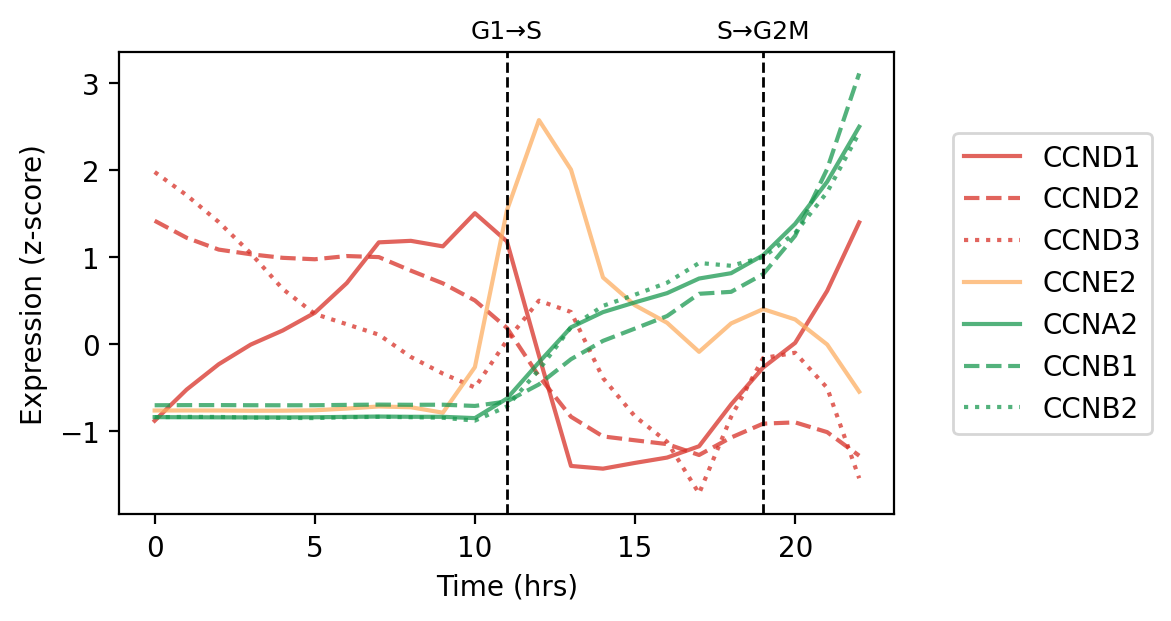

In [42]:
df = aggdata.to_df(layer='mean')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3

cyclin_genes = {
    # G1 cyclins
    "CCND1" : "#D73027", 
    "CCND2" : "#D73027", 
    "CCND3" : "#D73027",
    # G1/S cyclins
    "CCNE2"  : "#FDAE61",      
    # M cyclins
    "CCNA2" : "#1A9850",  
    "CCNB1" : "#1A9850",
    "CCNB2" : "#1A9850",
}

# distinct linestyles
linestyles = ["-", "--", ":", "-", "-", "--", ":",]

# assign one per gene (repeat if more genes than styles)
ls_map = {gene: linestyles[i % len(linestyles)] 
          for i, gene in enumerate(cyclin_genes.keys())}


for gene, color in cyclin_genes.items():
    x=df.index.astype(float).values
    y=zscore(df[gene].values)

    win = 5 if len(y) >= 7 else (len(y)//2)*2 + 1  # odd, ≤ len(y)
    y_sg = savgol_filter(y, window_length=win, polyorder=2, mode='interp')

    sns.lineplot(
        x=x, y=y_sg,
        lw=1.5, 
        alpha=0.75,
        label=gene,
        color=color,
        linestyle=ls_map[gene]
    )


order = ['G1','S','G2M']
ax = plt.gca()
trans = blended_transform_factory(ax.transData, ax.transAxes)

cum = 0.0
for i, phase in enumerate(order[:-1]):
    cum += dur_h[phase]  # boundary after this phase
    ax.axvline(cum, ls='--', lw=1, color='k')
    ax.text(cum, 1.02, f"{phase}→{order[i+1]}",
            transform=trans, ha='center', va='bottom',
            fontsize=9, clip_on=False)  # top of plot

plt.ylabel('Expression (z-score)')
plt.xlabel('Time (hrs)')

sns.move_legend(
    plt.gca(),
    title="",
    loc='center right',
    bbox_to_anchor=(1.35, 0.5)
)

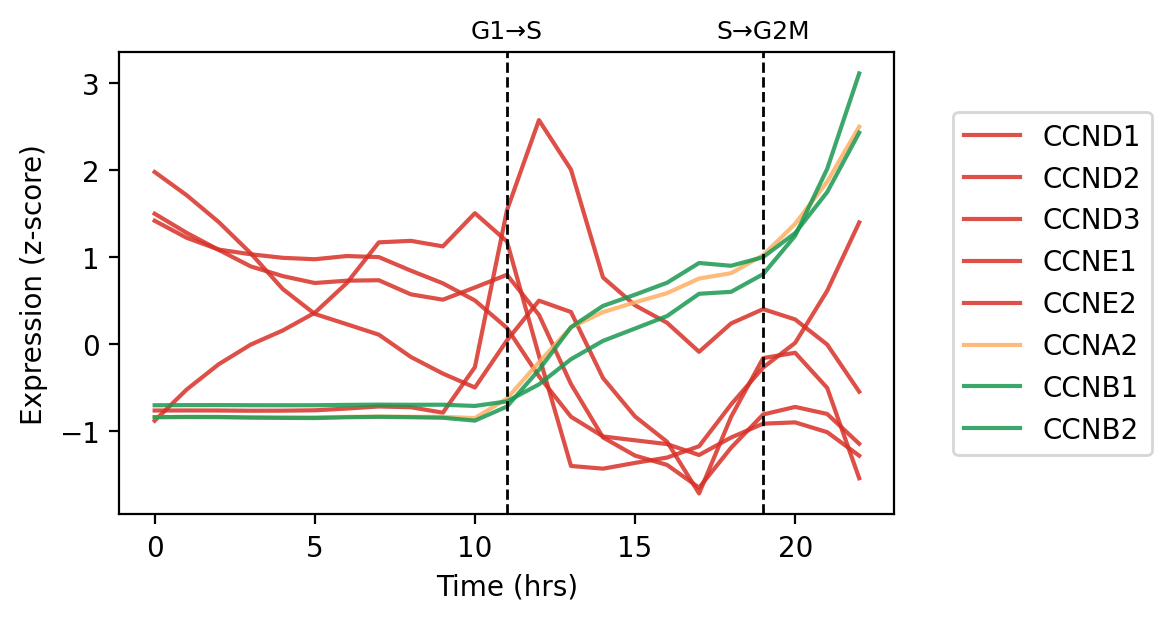

In [20]:
# ---- map cyclins to groups ----
cyclin_groups = {
    "CCND1": "G1",  "CCND2": "G1",  "CCND3": "G1",
    "CCNE1": "G1/S","CCNE2": "G1/S",
    "CCNA1": "S",   "CCNA2": "S",
    "CCNB1": "M",   "CCNB2": "M",
}

# given palette
phase_palette = {
    "G1": "#D73027",        
    "S": "#FDAE61",       
    "G2M": "#1A9850",    
}

# extend for cyclin groups (map G1/S → G1 color, M → G2M color)
group_colors = {
    "G1": phase_palette["G1"],
    "G1/S": phase_palette["G1"],
    "S": phase_palette["S"],
    "M": phase_palette["G2M"],
}

df = aggdata.to_df(layer='mean')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (5, 3)

cyclin_genes = [g for g in cyclin_groups if g in adata.var_names]

for gene in cyclin_genes:
    x = df.index.astype(float).values
    y = zscore(df[gene].values)
    win = 5 if len(y) >= 7 else (len(y)//2)*2 + 1
    y_sg = savgol_filter(y, window_length=win, polyorder=2, mode='interp')

    grp = cyclin_groups[gene]
    sns.lineplot(
        x=x, y=y_sg,
        lw=1.5, alpha=0.85,
        label=gene,
        color=group_colors[grp]
    )

# phase boundaries
order = ['G1','S','G2M']
ax = plt.gca()
trans = blended_transform_factory(ax.transData, ax.transAxes)

cum = 0.0
for i, phase in enumerate(order[:-1]):
    cum += dur_h[phase]
    ax.axvline(cum, ls='--', lw=1, color='k')
    ax.text(cum, 1.02, f"{phase}→{order[i+1]}",
            transform=trans, ha='center', va='bottom',
            fontsize=9, clip_on=False)

plt.ylabel('Expression (z-score)')
plt.xlabel('Time (hrs)')

sns.move_legend(
    ax,
    title="",
    loc='center right',
    bbox_to_anchor=(1.35, 0.5)
)
